In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("ToyotaCorolla - MLR.csv")

print(df.head())

   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  


In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("Dataset Information:")
df.info()

print(df.describe())

Shape of Dataset:
(1436, 11)

Column Names:
['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']

First 5 Rows:
   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 

In [8]:
#missing values
print("Missing Values:")
print(df.isnull().sum())

#duplicate values
print("Number of Duplicate Rows:")
print(df.duplicated().sum())

#drop
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns

print("Numerical Columns:")
print(numerical_columns.tolist())

print("\nCategorical Columns:")
print(categorical_columns.tolist())

Missing Values:
Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64
Number of Duplicate Rows:
0
Shape after removing duplicates:
(1435, 11)
Numerical Columns:
['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']

Categorical Columns:
['Fuel_Type']


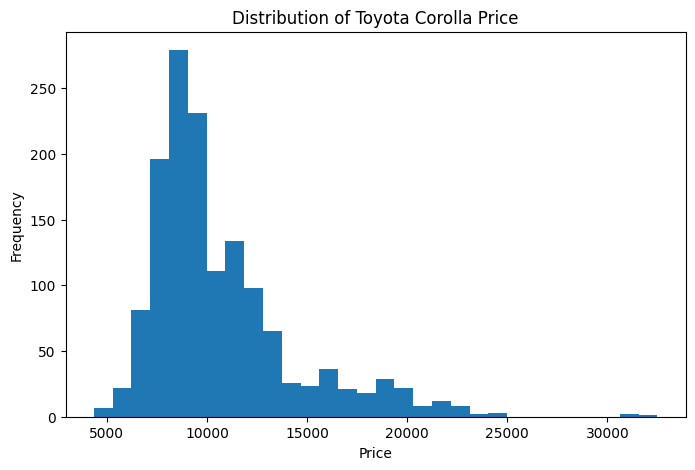

In [9]:
#EDA price distribution
plt.figure(figsize=(8, 5))

plt.hist(df['Price'], bins=30)

plt.title("Distribution of Toyota Corolla Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

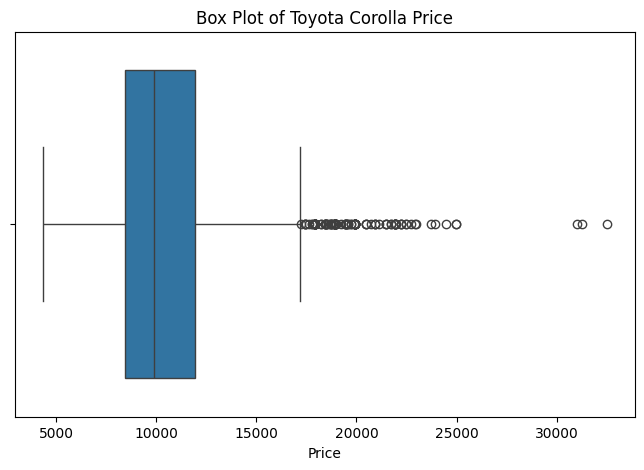

In [10]:
#Price Box Plot
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Price'])

plt.title("Box Plot of Toyota Corolla Price")
plt.xlabel("Price")

plt.show()

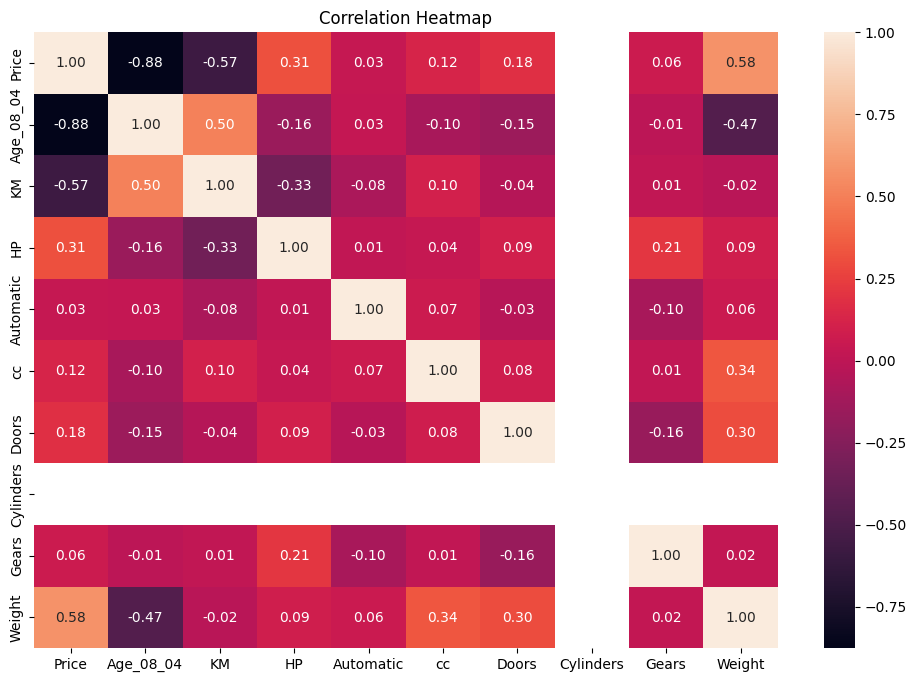

In [11]:
#Correlation Heatmap
plt.figure(figsize=(12, 8))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

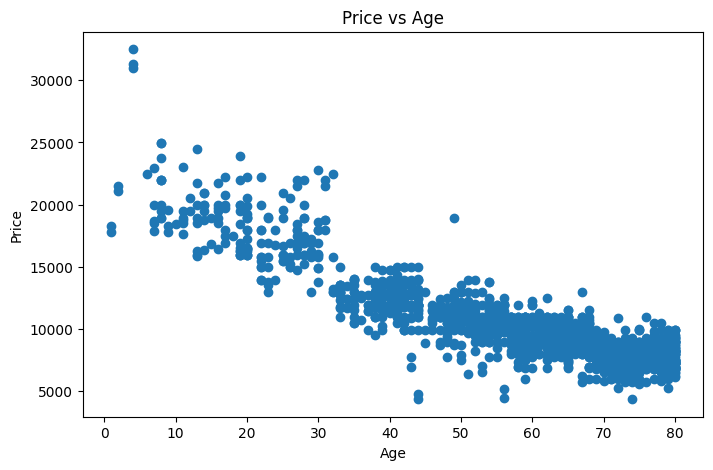

In [12]:
#Scatter Plot: Price vs Age
plt.figure(figsize=(8, 5))

plt.scatter(df['Age_08_04'], df['Price'])

plt.title("Price vs Age")
plt.xlabel("Age")
plt.ylabel("Price")

plt.show()

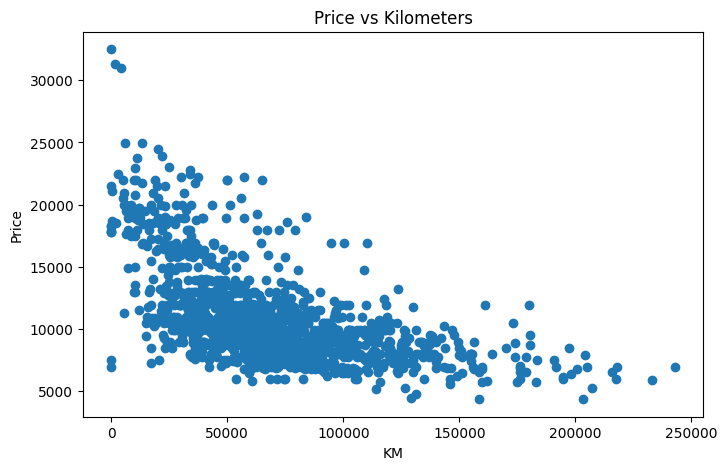

In [13]:
#Scatter Plot: Price vs KM
plt.figure(figsize=(8, 5))

plt.scatter(df['KM'], df['Price'])

plt.title("Price vs Kilometers")
plt.xlabel("KM")
plt.ylabel("Price")

plt.show()

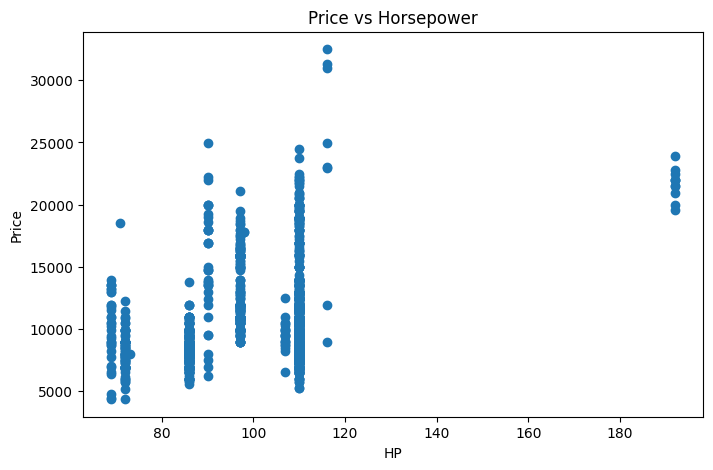

In [14]:
#Scatter Plot: Price vs HP
plt.figure(figsize=(8, 5))

plt.scatter(df['HP'], df['Price'])

plt.title("Price vs Horsepower")
plt.xlabel("HP")
plt.ylabel("Price")

plt.show()

Fuel_Type
Petrol    1264
Diesel     154
CNG         17
Name: count, dtype: int64


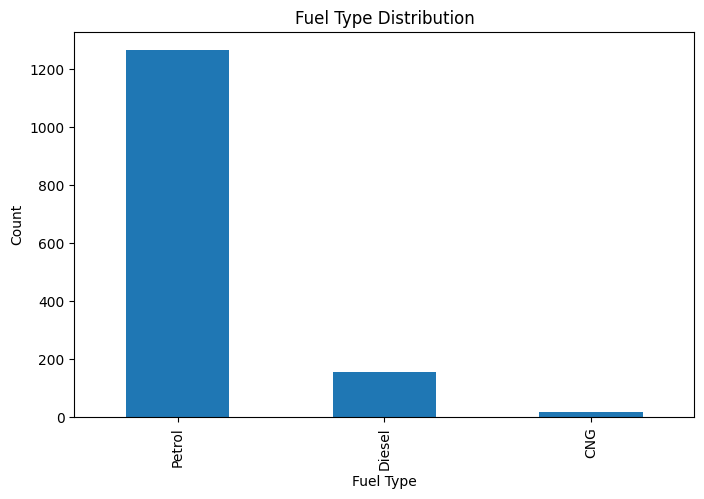

In [15]:
#Categorical Analysis
print(df['Fuel_Type'].value_counts())

#bar chart
plt.figure(figsize=(8, 5))

df['Fuel_Type'].value_counts().plot(kind='bar')

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.show()

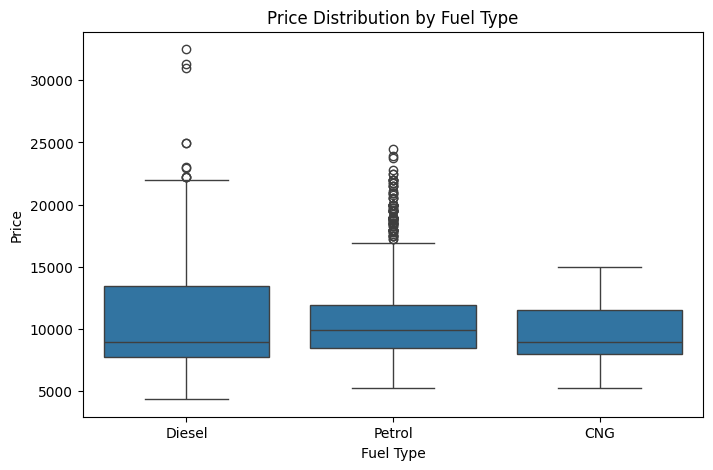

In [16]:
#Price by Fuel Type
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Fuel_Type',
    y='Price',
    data=df
)

plt.title("Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price")

plt.show()

In [18]:
X = df.drop('Price', axis=1)
y = df['Price']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Features:
   Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  Gears  \
0         23  46986    Diesel  90          0  2000      3          4      5   
1         23  72937    Diesel  90          0  2000      3          4      5   
2         24  41711    Diesel  90          0  2000      3          4      5   
3         26  48000    Diesel  90          0  2000      3          4      5   
4         30  38500    Diesel  90          0  2000      3          4      5   

   Weight  
0    1165  
1    1165  
2    1165  
3    1165  
4    1170  

Target:
0    13500
1    13750
2    13950
3    14950
4    13750
Name: Price, dtype: int64
Training data: (1148, 10)
Testing data: (287, 10)


In [20]:
#One-Hot Encoding
categorical_features = ['Fuel_Type']

numerical_features = [
    'Age_08_04',
    'KM',
    'HP',
    'Automatic',
    'cc',
    'Doors',
    'Cylinders',
    'Gears',
    'Weight'
]


preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(drop='first', handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

# **Model 1 — Multiple Linear Regression**

In [22]:
#building a model
model_1 = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

model_1.fit(X_train, y_train)


#predict
y_pred_1 = model_1.predict(X_test)

print("First 10 Predictions:")
print(y_pred_1[:10])

#Evaluate Model 1
mae_1 = mean_absolute_error(y_test, y_pred_1)

mse_1 = mean_squared_error(y_test, y_pred_1)

rmse_1 = np.sqrt(mse_1)

r2_1 = r2_score(y_test, y_pred_1)

print("Model 1 - Linear Regression")
print("MAE:", mae_1)
print("MSE:", mse_1)
print("RMSE:", rmse_1)
print("R² Score:", r2_1)

First 10 Predictions:
[10807.90535561 10326.70702975  9168.77441876  9347.15626531
  8470.34132486  8543.65542432  7890.51491252  8267.18515775
 11740.09825166 12334.33673916]
Model 1 - Linear Regression
MAE: 986.4966877483988
MSE: 2155628.356139875
RMSE: 1468.2058289422075
R² Score: 0.8203213869961599


# **Model 2 — Standardized Multiple Linear Regression**

In [23]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(drop='first', handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            StandardScaler(),
            numerical_features
        )
    ]
)


model_2 = Pipeline(
    steps=[
        ('preprocessor', preprocessor_scaled),
        ('regressor', LinearRegression())
    ]
)

model_2.fit(X_train, y_train)



#predict
y_pred_2 = model_2.predict(X_test)


#evaluate
mae_2 = mean_absolute_error(y_test, y_pred_2)
mse_2 = mean_squared_error(y_test, y_pred_2)
rmse_2 = np.sqrt(mse_2)
r2_2 = r2_score(y_test, y_pred_2)

print("Model 2 - Standardized Linear Regression")
print("MAE:", mae_2)
print("MSE:", mse_2)
print("RMSE:", rmse_2)
print("R² Score:", r2_2)

Model 2 - Standardized Linear Regression
MAE: 986.4966877482531
MSE: 2155628.356139625
RMSE: 1468.2058289421225
R² Score: 0.8203213869961807


# **Model 3 — Linear Regression Without Weak Predictors**

In [24]:
selected_features = [
    'Age_08_04',
    'KM',
    'HP',
    'Weight',
    'cc',
    'Fuel_Type'
]

X_selected = df[selected_features]
y = df['Price']

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42
)


categorical_selected = ['Fuel_Type']

numerical_selected = [
    'Age_08_04',
    'KM',
    'HP',
    'Weight',
    'cc'
]

preprocessor_3 = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(drop='first', handle_unknown='ignore'),
            categorical_selected
        ),
        (
            'numerical',
            StandardScaler(),
            numerical_selected
        )
    ]
)


#build
model_3 = Pipeline(
    steps=[
        ('preprocessor', preprocessor_3),
        ('regressor', LinearRegression())
    ]
)

model_3.fit(X_train_3, y_train_3)


#predict
y_pred_3 = model_3.predict(X_test_3)

#evaluate
mae_3 = mean_absolute_error(y_test_3, y_pred_3)
mse_3 = mean_squared_error(y_test_3, y_pred_3)
rmse_3 = np.sqrt(mse_3)
r2_3 = r2_score(y_test_3, y_pred_3)

print("Model 3 - Selected Features")
print("MAE:", mae_3)
print("MSE:", mse_3)
print("RMSE:", rmse_3)
print("R² Score:", r2_3)

Model 3 - Selected Features
MAE: 985.0924799745279
MSE: 2158363.7270726254
RMSE: 1469.137068851176
R² Score: 0.8200933849596086


# **Compare All Three Models**

In [25]:
results = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Standardized Linear Regression',
        'Selected Feature Regression'
    ],
    'MAE': [
        mae_1,
        mae_2,
        mae_3
    ],
    'MSE': [
        mse_1,
        mse_2,
        mse_3
    ],
    'RMSE': [
        rmse_1,
        rmse_2,
        rmse_3
    ],
    'R2 Score': [
        r2_1,
        r2_2,
        r2_3
    ]
})

print(results)

                            Model         MAE           MSE         RMSE  \
0      Multiple Linear Regression  986.496688  2.155628e+06  1468.205829   
1  Standardized Linear Regression  986.496688  2.155628e+06  1468.205829   
2     Selected Feature Regression  985.092480  2.158364e+06  1469.137069   

   R2 Score  
0  0.820321  
1  0.820321  
2  0.820093  


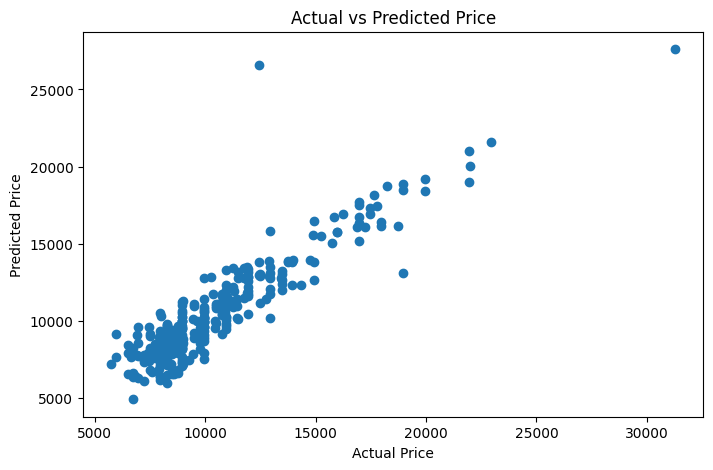

In [26]:
#Actual vs Predicted Plot
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_1)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

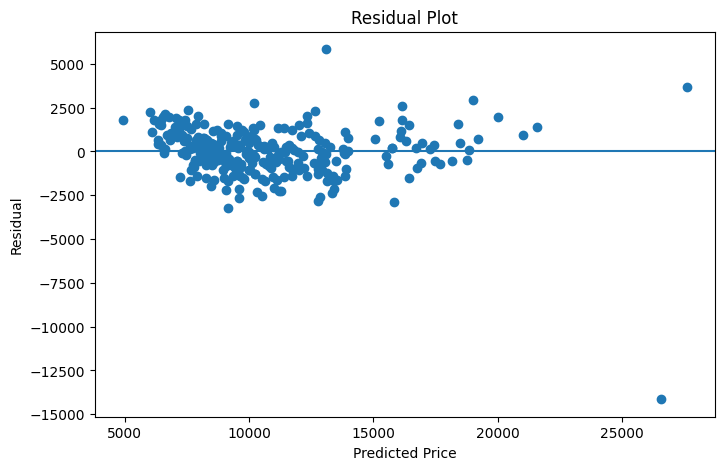

In [27]:
#Residual Plot
residuals = y_test - y_pred_1

plt.figure(figsize=(8, 5))

plt.scatter(y_pred_1, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [28]:
#Ridge Regression
ridge_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor_scaled),
        ('regressor', Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)


#Evaluate
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

ridge_mse = mean_squared_error(y_test, y_pred_ridge)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R² Score:", ridge_r2)

Ridge Regression
MAE: 986.820340681556
MSE: 2149447.1969835325
RMSE: 1466.0993134789787
R² Score: 0.8208366066539474


In [29]:
#Lasso Regression
lasso_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor_scaled),
        ('regressor', Lasso(alpha=0.1, max_iter=10000))
    ]
)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)


#Evaluate
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

lasso_mse = mean_squared_error(y_test, y_pred_lasso)

lasso_rmse = np.sqrt(lasso_mse)

lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso Regression")
print("MAE:", lasso_mae)
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)
print("R² Score:", lasso_r2)

Lasso Regression
MAE: 986.44470542613
MSE: 2154539.3521582983
RMSE: 1467.8349199274073
R² Score: 0.8204121590090665


In [30]:
#Final model comprasion
final_results = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Standardized Linear Regression',
        'Selected Feature Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MAE': [
        mae_1,
        mae_2,
        mae_3,
        ridge_mae,
        lasso_mae
    ],
    'RMSE': [
        rmse_1,
        rmse_2,
        rmse_3,
        ridge_rmse,
        lasso_rmse
    ],
    'R2 Score': [
        r2_1,
        r2_2,
        r2_3,
        ridge_r2,
        lasso_r2
    ]
})

print(final_results)

                            Model         MAE         RMSE  R2 Score
0      Multiple Linear Regression  986.496688  1468.205829  0.820321
1  Standardized Linear Regression  986.496688  1468.205829  0.820321
2     Selected Feature Regression  985.092480  1469.137069  0.820093
3                Ridge Regression  986.820341  1466.099313  0.820837
4                Lasso Regression  986.444705  1467.834920  0.820412


In [31]:
#Interpret Regression Coefficients
feature_names = model_1.named_steps[
    'preprocessor'
].get_feature_names_out()

coefficients = model_1.named_steps[
    'regressor'
].coef_

coefficient_table = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

print(coefficient_table)

                          Feature   Coefficient
0   categorical__Fuel_Type_Diesel -3.896838e+02
1   categorical__Fuel_Type_Petrol  1.128933e+03
2            numerical__Age_08_04 -1.212292e+02
3                   numerical__KM -1.599715e-02
4                   numerical__HP  1.607544e+01
5            numerical__Automatic  2.688222e+02
6                   numerical__cc -4.710949e-02
7                numerical__Doors -8.809716e+01
8            numerical__Cylinders -2.074785e-12
9                numerical__Gears  4.550119e+02
10              numerical__Weight  2.636120e+01


# **Interview Questions**



1. What is Normalization and Standardization?

* Normalization : Normalization generally scales values to a fixed range, commonly 0 to 1.

Formula:
x_normalized = (x - min(x)) / (max(x) - min(x))

It is useful when variables have very different ranges and a bounded scale is desirable.

* Standardization : Standardization transforms a variable so that it has approximately:

Mean = 0
Standard deviation = 1

Formula:

z = (x - mean) / standard deviation

Standardization is especially useful for algorithms such as Ridge and Lasso regression, because regularization penalizes coefficient sizes and therefore features should generally be on comparable scales.


2. Techniques to Address Multicollinearity

Techniques for Handling Multicollinearity
* Remove highly correlated predictors
If two predictors provide similar information, one can be removed.
* Variance Inflation Factor (VIF)
VIF can be used to identify predictors that have strong linear relationships with other predictors.
* Ridge Regression
Ridge adds an L2 penalty and can reduce the impact of multicollinearity.
* Lasso Regression
Lasso adds an L1 penalty and can shrink some coefficients toward zero, which can help with feature selection.
* Principal Component Analysis (PCA)
Correlated variables can be transformed into a smaller number of uncorrelated principal components.

# **Assumptions of Multiple Linear Regression**

1. Linearity
The relationship between predictors and the target variable should be approximately linear.
2. Independence
Observations should be independent of one another.
3. Homoscedasticity
The variance of residuals should remain approximately constant across predicted values.
4. Normality of residuals
Residuals should be approximately normally distributed, particularly for reliable statistical inference.
5. Low multicollinearity
Predictors should not have excessively strong linear relationships with each other.

* Implications

Violations of these assumptions can reduce model reliability. For example, strong multicollinearity can make coefficient estimates unstable, while heteroscedasticity can affect the reliability of standard errors. Residual plots and correlation analysis can help identify potential problems.

# **Conclusion**
Multiple linear regression was used to predict the price of Toyota Corolla vehicles based on available vehicle characteristics. Exploratory data analysis was first performed using statistical summaries, distribution plots, categorical analysis, scatter plots, and a correlation heatmap. The categorical Fuel_Type variable was converted into numerical form using one-hot encoding, and the data was divided into training and testing sets using an 80:20 ratio.

Three different linear regression models were developed and evaluated using MAE, MSE, RMSE, and R². Ridge and Lasso regression were also applied to reduce the effects of multicollinearity and overfitting. The models were compared based on their prediction errors and R² scores, with lower error and higher R² indicating better performance.

The analysis demonstrates that vehicle characteristics such as age, kilometers, horsepower, engine capacity, and weight can be used to explain variations in Toyota Corolla prices. Regularized models such as Ridge and Lasso provide alternative approaches when predictors are correlated or when controlling model complexity is important.